# **Lab 7: LDP using CDC**

Lecturer: `Sirasit Lochanachit`


Course: `06026213 Big Data Systems`

Term: `02/2025`

Lab materials prepared by `Sasithorn (TA) - 2025`

# Example: ETL pipeline using change data capture (CDC)

ในตัวอย่างนี้จะใช้ data จาก `customers` table ใน MySQL database เพื่อทำการ
- Extract change จาก transactional database แล้วบันทึกลง cloud object storage 
    - ในตัวอย่างนี้เราจะไม่ setup external CDC system แต่จะใช้การ generate fake data แทน
- ใช้ Auto Loader ในการ load messages จาก cloud object storate แบบ incremental และเก็บ raw message ใน `customers_cdc` table
- สร้าง `customers_cdc_clean` table เพื่อ check data quality เช่น `id` ไม่ควรมีค่า null
- run `AUTO CDC ... INTO` บน CDC data ที่ clean แล้วเพื่อ upsert change ไปยัง final `customers` table

เป้าหมายคือการ ingest raw data แบบใกล้เคียง real time และสร้าง table สำหรับทีม analyst ในขณะที่ data quality ยังคงมีอยู่

Architecture ของตัวอย่างนี้จะใช้ medallion Lakehouse ซึ่งเริ่มจากการ ingest raw data ใน bronze layer, จากนั้น clean และ validate data ใน silver layer และท้ายสุดทำ modeling และ aggregation ใน gold layer

![Implement_flow](https://docs.databricks.com/aws/en/assets/images/dlt_tutorial_cdc_pipeline-67c71b9b87b8463d77a9ef709725a575.png)

[อะไรคือ CDC](https://docs.databricks.com/aws/en/ldp/what-is-change-data-capture) Document

## CDC in an ETL pipeline

CDC คือกระบวนการหนึ่งที่บันทึกการเปลี่ยนแปลงของ record ที่เกิดขึ้นใน transactional database (เช่น MySQL, PostgreSQL) หรือ data warehouse โดย CDC จะตรวจจับพวกการดำเนินการต่างๆเช่น การลบ การเพิ่ม หรือการ update ข้อมูล โดยทั่วไปจะแสดงออกมาเป็น Stream เพื่อสร้างเป็นตารางใหม่ในปลายทาง และนอกจากนี้ cdc ยังช่วยให้สามารถ load ข้อมูลแบบ incremental ได้

## Capturing CDC

ในตัวอย่างนี้ นี้เราจะใช้ข้อมูล CDC จากภายนอกอย่าง Debezium (or DMS) โดย Debezium จะจับทุกแถวที่มีการเปลี่ยนแปลง และส่งประวัติการเปลี่ยนแปลงไปยัง Kafka topics หรือเซฟเป็นไฟล์

ในที่นี้เราจะทำการดึงข้อมูล CDC จากตารางที่ชื่อ customers → ตรวจว่าข้อมูลครบถ้วนถูกต้องมั้ย → แล้วสร้างตาราง customers ขึ้นใน Lakehouse

## CDC input from Debezium

ในทุกครั้งที่เปลี่ยนแปลง เราจะได้รับข้อมูล JSON ที่มี field ทั้งหมดของแถวที่ update (id, firstename, lastname, email, address) โดยข้อความจะมี metadata เพิ่มเติมคือ

- operation : operation code ต่างๆ (`DELETE`, `APPEND`, `UPDATE)`
- operation_date : วันและเวลาที่ลงสำหรับ record ในแต่ละ operaion

ตัว Tools ตัวนี้สามารถสร้าง output อื่น ๆ ได้อีก เช่น ข้อมูลในแถวก่อนที่จะเปลี่ยนแปลง

# Step 1: Create a pipeline

1. ทำเหมือนข้อ 1-7 ในตัวอย่างที่ 1 แต่ตั้งชื่อ pipeline ว่า `Pipelines with CDC tutorial`

# Step 2: Create the sample data to import

1. ใน pipeline assets browser ตรงแถบด้านซ้าย ที่มี folder pipeline ของเรา ให้คลิก + จากนั้นคลิก `Exploration`
2. ตั้งชื่อ `CDC Setup Data` แล้วเลือก notebook ให้เป็น Python, พอเราสร้างไฟล์มาแล้ว ไฟล์ที่สร้างใน explorations folder จะไม่ถูก run เป็นส่วนหนึ่งของ pipeline โดย default
3. คลิก Create

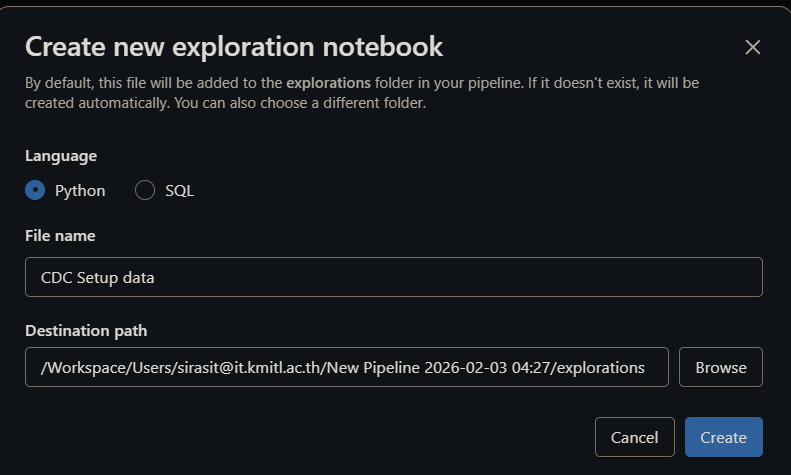

4. Copy code ด้านล่างใส่ลงใน Notebook จากนั้น run code
- อย่าลืมกำหนด catalog และ schema ให้ถูกต้อง

In [ ]:
%pip install faker
# Update these to match the catalog and schema
# that you used for the pipeline in step 1.

In [ ]:
catalog = "workspace"
schema = dbName = db = "default"

spark.sql(f'USE CATALOG `{catalog}`')
spark.sql(f'USE SCHEMA `{schema}`')
spark.sql(f'CREATE VOLUME IF NOT EXISTS `{catalog}`.`{db}`.`cdc_raw_data`')
volume_folder =  f"/Volumes/{catalog}/{db}/cdc_raw_data"

try:
  dbutils.fs.ls(volume_folder+"/customers")
except:
  print(f"folder doesn't exist, generating the data under {volume_folder}...")
  from pyspark.sql import functions as F
  from faker import Faker
  from collections import OrderedDict
  import uuid
  fake = Faker()
  import random

  fake_firstname = F.udf(fake.first_name)
  fake_lastname = F.udf(fake.last_name)
  fake_email = F.udf(fake.ascii_company_email)
  fake_date = F.udf(lambda:fake.date_time_this_month().strftime("%m-%d-%Y %H:%M:%S"))
  fake_address = F.udf(fake.address)
  operations = OrderedDict([("APPEND", 0.5),("DELETE", 0.1),("UPDATE", 0.3),(None, 0.01)])
  fake_operation = F.udf(lambda:fake.random_elements(elements=operations, length=1)[0])
  fake_id = F.udf(lambda: str(uuid.uuid4()) if random.uniform(0, 1) < 0.98 else None)

  df = spark.range(0, 100000).repartition(100)
  df = df.withColumn("id", fake_id())
  df = df.withColumn("firstname", fake_firstname())
  df = df.withColumn("lastname", fake_lastname())
  df = df.withColumn("email", fake_email())
  df = df.withColumn("address", fake_address())
  df = df.withColumn("operation", fake_operation())
  df_customers = df.withColumn("operation_date", fake_date())
  df_customers.repartition(100).write.format("json").mode("overwrite").save(volume_folder+"/customers")
     

5. หากต้องการดูข้อมูล ให้ใส่ code ด้านล่างนี้ลงไปใน notebook

In [ ]:
catalog = "workspace"
schema = "default"

display(spark.read.json(f"/Volumes/{catalog}/{schema}/cdc_raw_data/customers"))

# Step 3: Incrementally ingest data with Auto Loader

ขั้นตอนนี้เป็นการ ingest raw data จาก (faked) cloud storage เข้ามาในส่วนของ bronze layer

ความท้าทายในการ ingest raw data แบบ incremental คือ
- ต้อง operate แบบ scale ได้ ก็คือสามารถ ingest ไฟล์ขนาดเล็กๆเป็นจำนวนล้านๆไฟล์ได้
- Infer schema และ JSON type ได้
- Handle ข้อมูลที่ไม่ถูกต้องตาม JSON schema
- รองรับ schema evolution เช่น มี column ใหม่เพิ่มเข้ามา

การใช้ Auto Loader จะช่วยกระบวนการ ingestion ได้

1. ในการที่จะ ingest CDC data ที่ไหลเข้ามาโดยใช้ Auto Loader ให้ copy code ด้านล่างไปวางไว้ในไฟล์ของ pipeline (my_transformation.py)

In [ ]:
from pyspark import pipelines as dp
from pyspark.sql.functions import *

# Replace with the catalog and schema name that
# you are using:
path = "/Volumes/workspace/default/cdc_raw_data/customers"


# Create the target bronze table
dp.create_streaming_table("customers_cdc_bronze", comment="New customer data incrementally ingested from cloud object storage landing zone")

# Create an Append Flow to ingest the raw data into the bronze table
@dp.append_flow(
  target = "customers_cdc_bronze",
  name = "customers_bronze_ingest_flow"
)
def customers_bronze_ingest_flow():
  return (
      spark.readStream
          .format("cloudFiles")
          .option("cloudFiles.format", "json")
          .option("cloudFiles.inferColumnTypes", "true")
          .load(f"{path}")
  )

2. กด Shift + Enter เพื่อ run query
- เสร็จสิ้นการทำ bronze layer data ซึ่งในขั้นตอนตอ่ไปจะเป็นการ clean data เพื่อสร้าง silver layer table

# Step 4: Cleanup and expectations to track data quality

เงื่อนไขที่ต้องการเพิ่มเติม (expectation) เพื่อ control data quality:
- `ID` ต้องไม่มีค่า null
- CDC operation type ต้องถูกต้อง
- JSON ต้องอ่านได้ถูกต้องโดยใข้ Auto Loader

หากมีแถวข้อมูลที่ไม่เข้าเงื่อนไขให้ทำการ drop ทิ้ง

1. บนแถบ pipeline assets browser sidebar ให้เลือกปุ่ม `+ Add` จากนั้นเลือก `Transformation`
2. ตั้งชื่อไฟล์ python ชื่อว่า exp_clean.py และแปะ code ด้านล่างีน้

In [ ]:
from pyspark import pipelines as dp
from pyspark.sql.functions import *

dp.create_streaming_table(
  name = "customers_cdc_clean",
  expect_all_or_drop = {"no_rescued_data": "_rescued_data IS NULL","valid_id": "id IS NOT NULL","valid_operation": "operation IN ('APPEND', 'DELETE', 'UPDATE')"}
  )

@dp.append_flow(
  target = "customers_cdc_clean",
  name = "customers_cdc_clean_flow"
)
def customers_cdc_clean_flow():
  return (
      spark.readStream.table("customers_cdc_bronze")
          .select("address", "email", "id", "firstname", "lastname", "operation", "operation_date", "_rescued_data")
  )

3. กด Shift + Enter เพื่อ run query
- จะสังเกตเห็นตารางเพิ่มมาจากเดิมอีก 1 ตาราง รวมถึงใน DAG จะเห็นขั้นตอนเพิ่มมาอีก 1 ขั้น

Note: หากคลิก run pipeline จะ run pipeline นี้ตั้งแต่ต้น ถ้ามีข้อมูลที่เปลี่ยนแปลงไป มันจะดึงข้อมูลนั้นเข้ามาตั้งแต่ bronze layer เลย
- การ run ทั้ง pipeline จะไม่ไปยุ่งกับ code ในส่วนของ explorations folder เพราะไม่ได้ใช้ใน pipeline

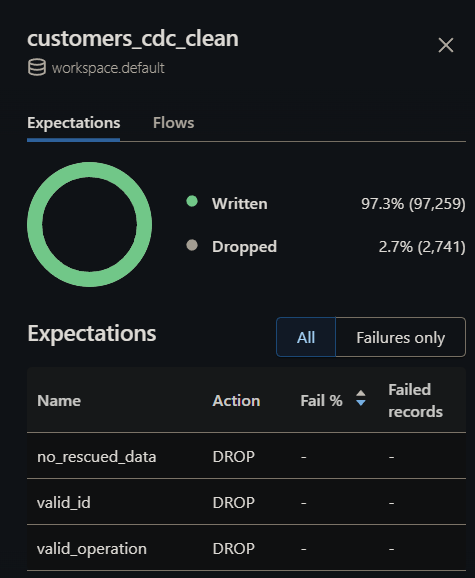

# Step 5: Materialize the customers table with an AUTO CDC flow (SCD Type 1)

ในขั้นตอนก่อนหน้านี้ ตารางต่าง ๆ เพียงแค่ส่งต่อ CDC data ในแต่ละขั้นตอน แต่ว่าในขั้นตอนนี้เราจะสร้าง customers table ที่มีทั้ง up-to-date view และ replica ของ original table
ซึ่งการทำด้วยตัวเองก็ไม่ง่าย เนื่องจากต้องคำนึงในเรื่องของการลบแถวที่ซ้ำซ้อนออกเพื่อเก็บตัวที่เป็นตัวล่าสุดไว้
- LDP จึงมีตัวช่วยจัดการเรื่องนี้โดยใช้ AUTO CDC Operation

1. บนแถบ pipeline assets browser sidebar ให้เลือกปุ่ม `+ Add` จากนั้นเลือก `Transformation`
2. ตั้งชื่อไฟล์ python ชื่อว่า cdcauto.py และแปะ code ด้านล่างีน้

In [ ]:
from pyspark import pipelines as dp
from pyspark.sql.functions import *

dp.create_streaming_table(name="customers", comment="Clean, materialized customers")

dp.create_auto_cdc_flow(
  target="customers",  # The customer table being materialized
  source="customers_cdc_clean",  # the incoming CDC
  keys=["id"],  # what we'll be using to match the rows to upsert
  sequence_by=col("operation_date"),  # de-duplicate by operation date, getting the most recent value
  ignore_null_updates=False,
  apply_as_deletes=expr("operation = 'DELETE'"),  # DELETE condition
  except_column_list=["operation", "operation_date", "_rescued_data"],
  stored_as_scd_type = 1,   # Default is 1, but you can also use 2 if you want to keep the history of changes
)

ใน code มีการใช้ dp.create_auto_cdc_flow เพื่อ process change data feed (CDF) to process the change data feed

Arguments:
- target: Target streaming table (ชื่อเดียวกันกับ streaming table ที่พึ่งสร้างขึ้นมา)
- source: แหล่งข้อมูลที่จะไหลเข้ามา (CDC)
- keys: unique identifier ใน CDF เพื่อทำการ match unique rows ใน change feed
- sequence_by: ชื่อ column ที่ระบุ logical order ของ CDC events ใน source data เพื่อที่จะจัดการ change events ที่เข้ามาแบบ out-of-order
- ignore_null_updates: หากเป็น True ใน column ที่มีค่า null ในตาราง update จะทำการเก็บค่าเดิมใน target table ไว้ แต่ถ้าหากเป็น False จะทำการเขียนทับด้วย null value
- apply_as_deletes: ระบุว่า CDC event ที่เป็น out-of-order ให้ทำการ DELETE แทนที่การ UPSERT
- except_column_list: list ของ columns ที่ไม่ต้องการบันทึกใน target table
- stored_as_scd_type: ระบุ scd type (Default: 1)

ตัวอย่าง out-of-order events

```python
# update these to the catalog and schema where you have permissions
# to create tables and views.

catalog = "mycatalog"
schema = "myschema"
employees_cdf_table = "employees_cdf"

def write_employees_cdf_to_delta():
 data = [
   (1, "Alex", "chef", "FR", "INSERT", 1),
   (2, "Jessica", "owner", "US", "INSERT", 2),
   (3, "Mikhail", "security", "UK", "INSERT", 3),
   (4, "Gary", "cleaner", "UK", "INSERT", 4),
   (5, "Chris", "owner", "NL", "INSERT", 6),
   # out of order update, this should be dropped from SCD Type 1
   (5, "Chris", "manager", "NL", "UPDATE", 5),
   (6, "Pat", "mechanic", "NL", "DELETE", 8),
   (6, "Pat", "mechanic", "NL", "INSERT", 7)
 ]
 columns = ["id", "name", "role", "country", "operation", "sequenceNum"]
 df = spark.createDataFrame(data, columns)
 df.write.format("delta").mode("overwrite").saveAsTable(f"{catalog}.{schema}.{employees_cdf_table}")

write_employees_cdf_to_delta()
```

3. กด Shift + Enter เพื่อ run query
- จะเห็นว่า pipeline graph แสดง 3 tables ซึ่งขยับจาก bronze ไปเป็น silver และไปเป็น gold

# Step 6: Track update history with slowly changing dimension type 2 (SCD2)

บ่อยครั้งที่เรามักจะสร้างตารางที่เก็บทุกการเปลี่ยนแปลงทั้งหมดจาก operation APPEND, UPDATE, DELETE

SCD2 with LDP

Delta table รองรับ CDF (Change Data Flow) และพวกการเปลี่ยนแปลงของตารางสามารถที่จะ query ดูได้ผ่าน SQL/Python แต่ทั้งนี้ทั้งนั้น CDF ใช้เพื่อ capture การเปลี่ยนแปลงของ pipeline ไม่ใช่เพื่อเก็บข้อมูลการเปลี่ยนแปลงของตารางทั้งหลายตั้งแต่เริ่ม และมันก็จะซับซ้อนขึ้นไปอีก ถ้ามี out-of-order events 
- นั่นก็คือหากเราต้องจัดลำดับการเปลี่ยนแปลงโดยอิงตาม timestamp ที่เกิดขึ้น แล้วการแก้ไขเก่าในอดีตมันถูกเพิ่มเข้ามาทีหลัง ก็จะต้องเพิ่มมันเข้าตารางและปรับข้อมูลก่อนหน้าให้เรียบร้อย

LDP จะมาช่วยลดความยากความซับซ้อนพวกนี้ และช่วยให้เราสร้างตารางแยกอันใหม่มาต่างหากที่จะเก็บการแก้ไขเปลี่ยนแปลงทั้งหลายตั้งแต่แรก ซึ่งมันจะ scale ได้ดี และจัดการพวก out-of-order event ให้ด้วย

1. คลิก + → Transformation → ตั้งชื่อ scd2.py → แปะโค้ด → run file

In [ ]:
from pyspark import pipelines as dp
from pyspark.sql.functions import *

# create the table
dp.create_streaming_table(
    name="customers_history", comment="Slowly Changing Dimension Type 2 for customers"
)

# store all changes as SCD2
dp.create_auto_cdc_flow(
    target="customers_history",
    source="customers_cdc_clean",
    keys=["id"],
    sequence_by=col("operation_date"),
    ignore_null_updates=False,
    apply_as_deletes=expr("operation = 'DELETE'"),
    except_column_list=["operation", "operation_date", "_rescued_data"],
    stored_as_scd_type="2",
)  # Enable SCD2 and store individual updates

Pipeline graph มี `customers_history` table ขึ้นมา

# Step 7: Create a materialized view that tracks who has changed their information the most

จาก step ที่แล้ว เราเก็บข้อมูลไว้ในตาราง customers_history แล้วว่าใครเปลี่ยนแปลงข้อมูลอะไรของตัวเองบ้าง ต่อมาเราจะสร้าง MV (Materialized View) ใน **gold layer** ที่จะบันทึกว่าใครเปลี่ยนแปลงแก้ไขข้อมูลของตัวเองบ่อยที่สุด ซึ่งเจ้าสิ่งนี้มันจะใช้ในการตรวจจับเรื่องพวกฉ้อโกง/หรือสร้าง user recommendations ในสถานการณ์จริงก็ได้ และนอกจากนี้ การใช้ scd2 ในการเปลี่ยนแปลงข้อมูลได้ทำการลบข้อมูลที่ซ้ำออกไปแล้ว เราก็จะสามารถนับจำนวนแถวต่อ user id ได้เลย

ทำเหมือนเดิมกับ step ที่ผ่านมา แต่ใช้โค้ดนี้ ใช้ชื่อไฟล์ว่า tracks.py

In [ ]:
from pyspark import pipelines as dp
from pyspark.sql.functions import *

@dp.table(
  name = "customers_history_agg",
  comment = "Aggregated customer history"
)
def customers_history_agg():
  return (
    spark.read.table("customers_history")
      .groupBy("id")
      .agg(
          count("address").alias("address_count"),
          count("email").alias("email_count"),
          count("firstname").alias("firstname_count"),
          count("lastname").alias("lastname_count")
      )
  )

Pipeline graph มี `customers_history_agg` table ขึ้นมา หลังจาก `customers_history`

ณ จุดนี้ถือว่า pipeline ครบถ้วนแล้ว สามารถทดสอบได้โดยการกดปุ่ม Run pipeline เพื่อเริ่มจากขั้นตอนแรก
- เหลือเพียงการกำหนด schedule ให้กับ pipeline ในการ update เป็นระยะๆ

# Step 8: Change Simulation

ใน data.ipynb ใน folder explorations เราจะเพิ่มมาอีก cell หนึ่ง เพื่อจำลองการเปลี่ยนแปลง

หาก run code ที่เป็นส่วนของการ generate data ใหม่หลายๆครั้ง พบว่า ด้วยความที่มันมี id, timestamp ใหม่ตลอด เลยทำให้ไม่เห็นชัดเจนว่ามันจับการเปลี่ยนแปลงและเก็บข้อมูลไว้ได้จริงๆหรือไม่

1. เราจะแปะโค้ดนี้ลงไปใน cell ใหม่

In [ ]:
from pyspark.sql import functions as F

# 1. sample data
existed = spark.read.json("/Volumes/workspace/default/cdc_raw_data/customers").sample(0.3).limit(2000).select("id", "firstname", "lastname", "email", "address")

# 2. update data
updates_df = existed.withColumn("operation_type_rand", F.rand()) \
    .withColumn("operation", 
        F.expr("CASE WHEN operation_type_rand > 0.3 THEN 'UPDATE' ELSE 'DELETE' END")) \
    .withColumn("firstname", 
        F.expr("CASE WHEN operation = 'UPDATE' THEN 'Updated_Name' ELSE firstname END")) \
    .withColumn("address", 
        F.lit("Updated Address")) \
    .withColumn("email", 
        F.lit("test@email.com")) \
    .withColumn("operation_date", F.current_timestamp()) \
    .withColumn("_rescued_data", F.lit(None)) \
    .drop("operation_type_rand")

# 3. Save file
path = "/Volumes/workspace/default/cdc_raw_data/customers"
updates_df.write.format("json").mode("append").save(path)

ซึ่งโค้ดข้างบนนี้ มันจะ…

    1. สุ่มข้อมูลมาโดยดึง id ที่มีอยู่แล้วมา
    2. ปรับข้อมูลต่างๆ คือ operation, firstname, address, และอื่น ๆ
    3. แล้ว save เข้าไปยังที่เก็บ data ที่ gen มาของเรา แบบ append (เพื่อไม่ให้กระทบข้อมูลจริง เลย save เป็น log ใหม่เข้าไป)

2. กด run เฉพาะ cell นี้ (ไม่ต้องรัน gen ข้อมูลใหม่แล้ว)

3. กด Run Pipeline แล้วสังเกตตาราง `customers_history_agg` 

---